<h1 style='color:#248c2a'> Indic Audio-to-Image Generation </h1>
<h3 style='color:#2bac22'> Team Cudavengers </h3>

Team Members:
- Bhavik Shanghari 
- Uday Bharadwaj
- Vedant Marodkar


In [3]:
!pip install -U bitsandbytes
!pip install stanza librosa torchaudio
!pip install indic-nlp-library sacremoses
# !pip install indic-nlp-library sacremoses bitsandbytes -q

# The GitHub repository was recently updated and also renamed from `IndicTransTokenizer` --> `IndicTransToolkit`
!git clone https://github.com/VarunGumma/IndicTransToolkit
%cd IndicTransToolkit
!python3 -m pip install --editable ./
%cd ..
# Clone the required Git repository for IndicTrans2
!git clone https://github.com/AI4Bharat/IndicTrans2.git
# Clone the Hugging face interface from github
%cd /content/IndicTrans2/huggingface_interface

!git clone https://github.com/VarunGumma/IndicTransToolkit

%cd IndicTransToolkit
!pip install --editable ./

fatal: destination path 'IndicTransToolkit' already exists and is not an empty directory.
/home/interiit/hp3/eng_Latn-hin_Deva/IndicTransToolkit/IndicTransToolkit
Obtaining file:///home/interiit/hp3/eng_Latn-hin_Deva/IndicTransToolkit/IndicTransToolkit
ERROR: file:///home/interiit/hp3/eng_Latn-hin_Deva/IndicTransToolkit/IndicTransToolkit does not appear to be a Python project: neither 'setup.py' nor 'pyproject.toml' found.
/home/interiit/hp3/eng_Latn-hin_Deva/IndicTransToolkit
Cloning into 'IndicTrans2'...
remote: Enumerating objects: 741, done.
remote: Counting objects: 100% (169/169), done.
remote: Compressing objects: 100% (67/67), done.
remote: Total 741 (delta 140), reused 105 (delta 102), pack-reused 572 (from 1)
Receiving objects: 100% (741/741), 4.14 MiB | 9.81 MiB/s, done.
Resolving deltas: 100% (482/482), done.
[Errno 2] No such file or directory: '/content/IndicTrans2/huggingface_interface'
/home/interiit/hp3/eng_Latn-hin_Deva/IndicTransToolkit
fatal: destination path 'Indic

## Importing all the libraries

In [4]:
import requests
import torch
from PIL import Image
from io import BytesIO
from diffusers import StableDiffusionImg2ImgPipeline
import torchaudio
from transformers import AutoModelForSpeechSeq2Seq, AutoProcessor, pipeline
import torch
from transformers import (
    AutoModelForSeq2SeqLM,
    AutoTokenizer,
)
from IndicTransToolkit import IndicProcessor
from transformers import BitsAndBytesConfig
from diffusers import StableDiffusionPipeline, EulerDiscreteScheduler
from diffusers import StableDiffusionImg2ImgPipeline
import stanza

stanza.download('hi')
import time
import matplotlib.pyplot as plt
import numpy as np
import librosa
import soundfile as sf
import IPython.display as ipd

2024-11-21 22:40:26 INFO: Downloaded file to /home/interiit/stanza_resources/resources.json
2024-11-21 22:40:26 INFO: Downloading default packages for language: hi (Hindi) ...
2024-11-21 22:40:27 INFO: File exists: /home/interiit/stanza_resources/hi/default.zip
2024-11-21 22:40:29 INFO: Finished downloading models and saved to /home/interiit/stanza_resources


### `TransGen`: Our Text-to-Image Converter 

The `TransGen` class is made in order to perform two major tasks:
1. __Translate text__: We have used the IndicTrans2 for the translation.
2. __Dynamic POS-based policy making__: During this, We have leveraged the feature of POS generated with the help of `stanza`.
3. __Generate an image__: For this, We have used two models: one for the base text to image for the first instance of input and another for image-to-image for further instance.

---

#### Translation Task

- `translation_model`: For translation task, default is `"ai4bharat/indictrans2-indic-en-1B"`, which is a model trained to translate from Indian languages to English.
- `src_lang`: The source language for translation, default is `hin_Deva`.
- `tgt_lang`: The target language for translation, default is `eng_Latn`.

This method translates a batch of input sentences from the source language to the target language.
- **Preprocessing (`self.ip.preprocess_batch`)**: The input sentences are preprocessed using the `IndicProcessor` to convert them into a format suitable for the model.
- **Tokenization (`self.tokenizer`)**: The sentences are tokenized using the translation model's tokenizer, ensuring they are padded and truncated as necessary.
- **Translation (`self.model.generate`)**: The preprocessed and tokenized sentences are passed through the translation model to generate translated tokens. The model uses beam search for more accurate translations (`num_beams=5`).
- **Postprocessing (`self.ip.postprocess_batch`)**: The translated tokens are decoded back into text using the tokenizer, and any postprocessing is applied (e.g., cleaning up spaces, formatting).
- **Return:** The translated sentences in the target language are returned.

#### Dynamic NER-based Policy

- For this task, we have used the NER api from `stanza` to develop a policy for simultaneous translation which uses POS tags as the centre feature.

#### Image Generation task
- `stable_diff_model`: For generating images, the default is `"stabilityai/stable-diffusion-2-base"`, a widely used pre-trained image generation model.
- `Image-to-Image Generation`: If a previous image is provided (`prev_image`), it uses the `img2img_pipe` to modify the previous image based on the prompt.
- `Text-to-Image Generation`: If no previous image is provided, it generates a completely new image. This is to handle the case when we are passing the initial part of source text.


#### Major Features:
- __Multilingual Translation__: It supports translating from Indian languages to English using an advanced translation model.
- __Image Generation from Text__: Stable Diffusion model is used to generate images from text descriptions, such as translated sentences.
- __Image Modification__: The class supports image-to-image generation, allowing us to modify an existing image based on a text prompt.
- __Optimized for Memory and Speed__: We have used quantization (4-bit precision) to reduce memory usage, making it suitable for large-scale translation and image generation tasks.

In [5]:
class TransGen:
  def __init__(self, translation_model = "ai4bharat/indictrans2-indic-en-1B",stable_diff_model = "stabilityai/stable-diffusion-2-base", src_lang = 'hin_Deva', tgt_lang = 'eng_Latn'):
    self.bnb_config = BitsAndBytesConfig(load_in_4bit=True)
    self.tokenizer = AutoTokenizer.from_pretrained(translation_model, trust_remote_code=True)
    self.model = AutoModelForSeq2SeqLM.from_pretrained(translation_model, trust_remote_code=True, quantization_config = self.bnb_config)
    self.ip = IndicProcessor(inference=True)
    self.src_lang = src_lang
    self.tgt_lang = tgt_lang

    scheduler = EulerDiscreteScheduler.from_pretrained(stable_diff_model, subfolder="scheduler")
    self.pipe = StableDiffusionPipeline.from_pretrained(stable_diff_model, scheduler=scheduler, torch_dtype=torch.bfloat16)
    self.pipe = self.pipe.to("cuda")

    self.img2img_pipe = StableDiffusionImg2ImgPipeline.from_pretrained(stable_diff_model, torch_dtype=torch.float16)
    self.img2img_pipe = self.img2img_pipe.to('cuda')

  def translate(self, input_sentences):
    batch = self.ip.preprocess_batch(
        input_sentences,
        src_lang=self.src_lang,
        tgt_lang=self.tgt_lang,
    )
    inputs = self.tokenizer(
        batch,
        truncation=True,
        padding="longest",
        return_tensors="pt",
        return_attention_mask=True,
    )

    with torch.no_grad():
      generated_tokens = self.model.generate(
          **inputs,
          use_cache=True,
          min_length=0,
          max_length=256,
          num_beams=5,
          num_return_sequences=1,
      )

    with self.tokenizer.as_target_tokenizer():
        generated_tokens = self.tokenizer.batch_decode(
            generated_tokens.detach().cpu().tolist(),
            skip_special_tokens=True,
            clean_up_tokenization_spaces=True,
        )

    translations = self.ip.postprocess_batch(generated_tokens, lang=self.tgt_lang)

    return translations

  def generate_image(self, prompt, prev_image, strength=1.0, guidance_scale=7.5):
      # Ensure strength and guidance_scale are float values
      strength = float(strength) if strength is not None else 1.0
      guidance_scale = float(guidance_scale) if guidance_scale is not None else 7.5
      
      # Ensure strength is between 0 and 1
      strength = max(0.0, min(1.0, strength))
      
      if prev_image is not None:
          image = self.img2img_pipe(
              prompt, 
              image=prev_image,
              strength=strength, 
              guidance_scale=guidance_scale,
              negative_prompt='generate text in image'
          ).images[0]
          return image
      
      image = self.pipe(prompt)
      return image.images[0]

  def run(self, input_sentences, strength, guidance_scale, prev_image=None ):
    translations = self.translate(input_sentences)
    sentence = translations[0]
    image = self.generate_image(sentence, prev_image, strength, guidance_scale)
    return sentence, image

transgen = TransGen()

`low_cpu_mem_usage` was None, now default to True since model is quantized.


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

### Transcription and Generation of image

- Here, We have integrated transcription of the given image with the multilingual prompt-to-image generation.
- During this task, `Whisper-large-v3` is used due to its high support which includes multiple languages.

- The method accepts an audio hindi file in `wav` format which is first transcribed and then, image is generated.
- An ASR pipeline is created using the `pipeline` function from Hugging Face. 
- The audio file specified by `audio_path` is loaded using `torchaudio.load`, which returns the audio waveform and its sample rate.
- The waveform is passed through the ASR pipeline for transcription.
- The transcription result is stored in the `result["text"]` field and printed to the console.
- The transcription text in Hindi is then returned by the function.

In [6]:
def transcribe_audio_to_hindi(audio_path: str) -> str:
    device = "cuda:0" if torch.cuda.is_available() else "cpu"
    torch_dtype = torch.float16 if torch.cuda.is_available() else torch.float32

    model_id = "openai/whisper-large-v3"
    model = AutoModelForSpeechSeq2Seq.from_pretrained(
        model_id, torch_dtype=torch_dtype, low_cpu_mem_usage=True, use_safetensors=True
    )
    model.to(device)

    processor = AutoProcessor.from_pretrained(model_id)

    whisper_pipe = pipeline(
        "automatic-speech-recognition",
        model=model,
        tokenizer=processor.tokenizer,
        feature_extractor=processor.feature_extractor,
        torch_dtype=torch_dtype,
        device=device,
        model_kwargs={"language": "hi"}  
    )

    waveform, sample_rate = torchaudio.load(audio_path)

    if sample_rate != 16000:
        resampler = torchaudio.transforms.Resample(orig_freq=sample_rate, new_freq=16000)
        waveform = resampler(waveform)

    result = whisper_pipe(waveform.squeeze(0).cpu().numpy(), return_timestamps=True)
    print(result['text'])
    return result["text"]


### `POS_policy`

We find the position of the last **noun** or **verb** using the **Stanza** library.

1. __Stanza Pipeline__:  
   We have initialized a Stanza pipeline for Hindi with tokenization and POS tagging (`tokenize,pos`).

2. __Processing Input__:  
   The input sentence is processed through the Stanza pipeline (`doc = nlp(lst)`), resulting in tokenized words with POS tags.

3. __Backward Iteration__:  
   The function starts from the last word and iterates backward.
4. **Return Position**:  
   If a noun or verb is found, its index is returned. If none are found, `0` is returned.
---

### Example

For the sentence "राम स्कूल जाता है", the function would:
- Tokenize it into words: `["राम", "स्कूल", "जाता", "है"]`
- POS tags: `राम (NOUN)`, `जाता (VERB)`, `है (AUX)`
- Return `2` as `जाता` is the last verb.


In [7]:
nlp = stanza.Pipeline(lang='hi', processors='tokenize,pos')

def POS_policy(input):
  lst = input
  doc = nlp(lst)
  words = doc.sentences[-1].words
  n= len(words)
  i= n-1
  while(i):
    if words[i].upos == 'NOUN' or words[i].upos == 'VERB':
      return i
    else:
      pass
    i-=1
  return 0

2024-11-21 22:40:39 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


2024-11-21 22:40:39 INFO: Downloaded file to /home/interiit/stanza_resources/resources.json
2024-11-21 22:40:40 INFO: Loading these models for language: hi (Hindi):
| Processor | Package     |
---------------------------
| tokenize  | hdtb        |
| pos       | hdtb_charlm |

2024-11-21 22:40:40 INFO: Using device: cuda
2024-11-21 22:40:40 INFO: Loading: tokenize
/home/interiit/miniconda3/envs/hp3/lib/python3.10/site-packages/stanza/models/tokenization/trainer.py:82: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no lo

### Complete Workflow

In [8]:
def generate_images_from_audio(audio_path, base_strength=0.8, base_guidance_scale=12):
    """
    Generate images incrementally based on transcribed audio text
    
    Args:
        audio_path (str): Path to the input audio file
        base_strength (float, optional): Base strength for image generation. Defaults to 0.
        base_guidance_scale (float, optional): Base guidance scale. Defaults to 12.
    
    Returns:
        list: Generated images and corresponding sentences
    """
    # Transcribe audio to text
    # Load the audio file
    audio_data, sr = librosa.load(audio_path, sr=None)  # sr=None keeps the original sample rate
    ipd.Audio(audio_data, rate=sr)

    text_tot = transcribe_audio_to_hindi(audio_path)
    
    print(f'Transcripted sentence: {text_tot}')
    # Initialize variables
    cur_sent = ''
    prev_idx = 0
    generated_images = []
    
    # Iterate through words in the transcribed text
    for word in text_tot.split():
        # Build current sentence
        cur_sent += word + ' '
        
        # Apply POS policy to determine image generation point
        str_idx = POS_policy(cur_sent)
        
        # Check if image generation is triggered
        if str_idx != 0 and str_idx != prev_idx:
            # Update tracking variables
            prev_idx = str_idx
            
            # Generate image with current sentence
            sent, image = transgen.run(
                [cur_sent], 
                base_strength, 
                base_guidance_scale, 
                image if 'image' in locals() else None
            )
            
            # Save and store image
            image_path = f'{cur_sent.replace(" ", "_")}.png'
            image.save(image_path)
            
            # Store generated image details
            generated_images.append({
                'sentence': cur_sent,
                'image_path': image_path,
                'image': image
            })
            
            # Optional: Display image (can be removed if not needed)
            plt.figure()
            plt.imshow(image)
            plt.axis('off')
            plt.title(sent)
            plt.pause(0.1)
    
    return generated_images

## Example Usage

In [12]:
# Provide the path to the audio file
audio_file = '/home/interiit/hp3/eng_Latn-hin_Deva/hindi_audio_4.wav'
audio_data, sr = librosa.load(audio_file, sr=None)
ipd.Audio(audio_data, rate=sr)

/home/interiit/miniconda3/envs/hp3/lib/python3.10/site-packages/transformers/models/whisper/generation_whisper.py:509: FutureWarning: The input name `inputs` is deprecated. Please make sure to use `input_features` instead.
  warnings.warn(


 काले पंखो वाला लाल ड्रैगन उड़ रहा है।
Transcripted sentence:  काले पंखो वाला लाल ड्रैगन उड़ रहा है।


/home/interiit/miniconda3/envs/hp3/lib/python3.10/site-packages/transformers/generation/utils.py:2097: UserWarning: You are calling .generate() with the `input_ids` being on a device type different than your model's device. `input_ids` is on cpu, whereas the model is on cuda. You may experience unexpected behaviors or slower generation. Please make sure that you have put `input_ids` to the correct device by calling for example input_ids = input_ids.to('cuda') before running `.generate()`.
  warnings.warn(
/home/interiit/miniconda3/envs/hp3/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:4114: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


  0%|          | 0/50 [00:00<?, ?it/s]

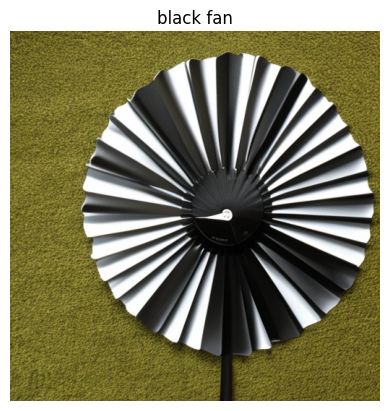

  0%|          | 0/40 [00:00<?, ?it/s]

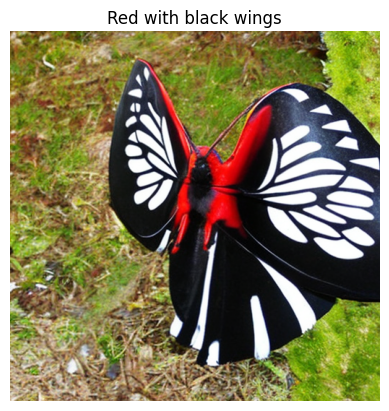

  0%|          | 0/40 [00:00<?, ?it/s]

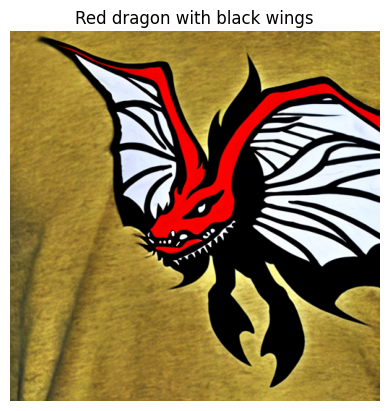

  0%|          | 0/40 [00:00<?, ?it/s]

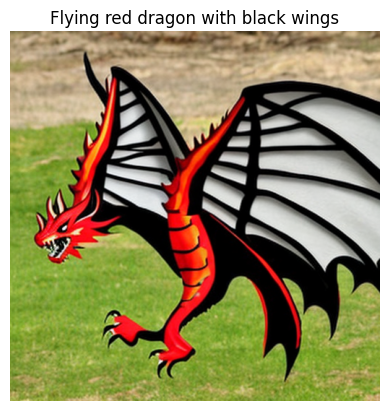

In [13]:
results = generate_images_from_audio(audio_file)